Using steering type: linear
Token position: last

[DEBUG] Available steering_keys for MMLU-HS / Llama-3.1-8B-Instruct:
  - additive_probe_1.0_all_layers_all_token_pos
  - no_steering
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_contrastive_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_logistic_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_exact
  - optimal_probe_1.0_all_layers_all_token_pos_calibrated_for_last
  - prompt_steering
  - vanilla_contrastive_1.0_k_100_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_200_sets_all_layers_all_token_pos
  - vanilla_contrastive_1.0_k_50_sets_all_layers_all_token_pos

[DEBUG] Available calibration targets:
  - 
  - exact
  - last
[WARN] No steering PKLs found for type 'linear' in /capstor/store/cscs/swissai/infra01/apertus_probes/mera-

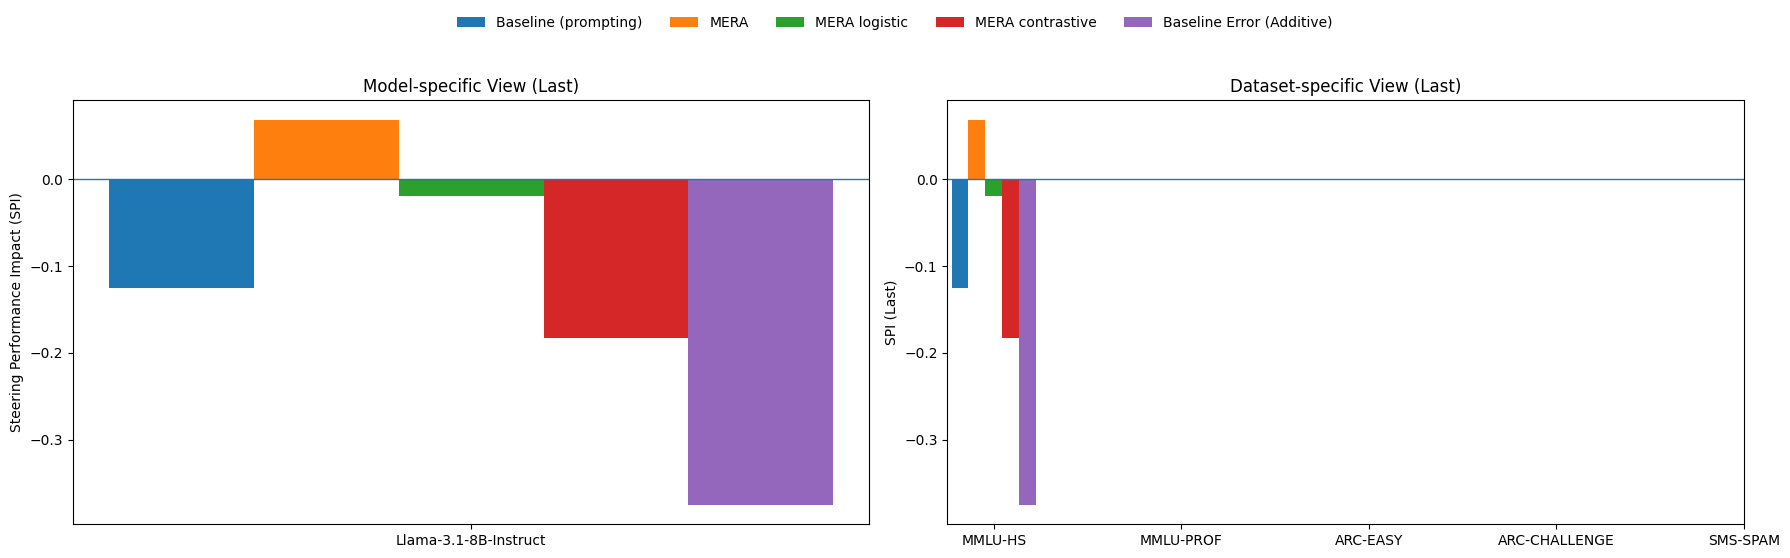

In [ ]:
import os
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths and config
# -----------------------------

ROOT = Path("/capstor/store/cscs/swissai/infra01/apertus_probes/mera-runs/steering_outputs")

DATASETS = {
    "MMLU-HS"      : "mmlu_high_school",
    "MMLU-PROF"    : "mmlu_professional",
    "ARC-EASY"     : "arc_easy",
    "ARC-CHALLENGE": "arc_challenge",
    "SMS-SPAM"     : "sms_spam",
}

MODELS = {
    # "Apertus-8B-2509"          : "Apertus-8B-2509",
    "Apertus-8B-Instruct-2509" : "Apertus-8B-Instruct-2509",
    "Llama-3.1-8B-Instruct" : "Llama-3.1-8B-Instruct",
    # "Meta-Llama-3-8B"          : "Meta-Llama-3-8B",
}

# METHODS: for MERA we give a priority list of prefixes
# Try multiple variants in order of preference
METHODS = {
    "Baseline (prompting)" : ["prompt_steering"],
    "MERA"            : [
        "optimal_probe_1.0_all_layers_all_token_pos_derive_all_with_both",
        "optimal_probe_1.0_all_layers_all_token_pos",  # fallback without derive_all_with_both
    ],
    "MERA logistic"   : [
        "optimal_logistic_probe_1.0_all_layers_all_token_pos_derive_all_with_both",
        "optimal_logistic_probe_1.0_all_layers_all_token_pos",  # fallback
    ],
    "MERA contrastive": [
        "optimal_contrastive_1.0_all_layers_all_token_pos_derive_all_with_both",
        "optimal_contrastive_1.0_all_layers_all_token_pos",  # fallback
    ],
    "Baseline Error (Additive)"        : ["additive_probe_1.0_all_layers_all_token_pos"],
}

CALIB_TARGET = "exact"   # for optimal_* methods: "exact", "last", or "both"
N_TEST       = 250
STEERING_TYPE = "logit"  # "linear", "logit", or None for all
TOKEN_POS = "last"  # "exact", "last", or "both" - which token position SPI to collect

print(f"Using steering type: {STEERING_TYPE if STEERING_TYPE else 'all'}")
print(f"Token position: {TOKEN_POS}")


# -----------------------------
# Helpers
# -----------------------------

def load_steering_results(dataset_folder: str, model_folder: str) -> pd.DataFrame:
    """Load and concat all *_steering_all_results.pkl for a (dataset, model)."""
    steering_dir = ROOT / dataset_folder / model_folder / "steering"
    if not steering_dir.exists():
        print(f"[WARN] Missing steering dir: {steering_dir}")
        return pd.DataFrame()

    pkl_paths = sorted(steering_dir.glob("*_steering_all_results.pkl"))
    
    # Filter by steering type if specified
    # Note: Files with "derive_all_with_both" may not have _logit_/_linear_ in name
    # (e.g., mmlu_hs_* vs mmlu_high_school_logit_*)
    if STEERING_TYPE is not None:
        filtered_paths = []
        for p in pkl_paths:
            # Include if it has the type in the name, OR if it has "derive_all_with_both" 
            # (which uses different naming convention)
            if f"_{STEERING_TYPE}_" in p.name or "derive_all_with_both" in p.name:
                filtered_paths.append(p)
        pkl_paths = filtered_paths
        if not pkl_paths:
            print(f"[WARN] No steering PKLs found for type '{STEERING_TYPE}' in {steering_dir}")
            return pd.DataFrame()
    
    if not pkl_paths:
        print(f"[WARN] No steering PKLs found in {steering_dir}")
        return pd.DataFrame()

    dfs = []
    for p in pkl_paths:
        with open(p, "rb") as f:
            obj = pickle.load(f)
        df = pd.DataFrame(obj)
        dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)

    # de-duplicate just in case
    needed = {"steering_key", "dataset_name", "alpha_calibration_token_pos_target"}
    if needed <= set(df.columns):
        df = df.drop_duplicates(
            subset=list(needed),
            keep="last",
        )

    return df


def pick_row_single(df: pd.DataFrame, key_prefix: str, calib: str | None):
    """Pick row whose steering_key starts with key_prefix (or equals for no_steering)."""
    if key_prefix == "no_steering":
        mask = df["steering_key"].eq("no_steering")
    else:
        mask = df["steering_key"].astype(str).str.startswith(key_prefix)
        if calib is not None and "alpha_calibration_token_pos_target" in df.columns:
            # Try both exact match and checking if calib is in the value
            calib_mask = df["alpha_calibration_token_pos_target"].fillna("").astype(str)
            # Check if calibration target matches (could be "exact" or contain "exact")
            calib_match = calib_mask.eq(calib) | calib_mask.str.contains(calib, na=False)
            mask &= calib_match

    sel = df[mask]
    if sel.empty:
        raise ValueError("no match")
    if len(sel) > 1:
        # just take the first, but warn
        print(f"[INFO] Multiple rows for {key_prefix}, taking first.")
    return sel.iloc[0]


def pick_row_multi(df: pd.DataFrame, key_prefixes: list[str], calib_target: str | None = None) -> pd.Series:
    """
    Try several prefixes in order (for MERA). For optimal_* we use calib_target (or CALIB_TARGET if not provided).
    Returns the first successful row.
    """
    if calib_target is None:
        calib_target = CALIB_TARGET
    last_err = None
    for prefix in key_prefixes:
        try:
            calib = calib_target if prefix.startswith("optimal_") else None
            return pick_row_single(df, prefix, calib)
        except Exception as e:
            last_err = e
            continue
    raise last_err or ValueError("no match in any prefix")


# -----------------------------
# Collect SPI + percentile data
# -----------------------------

records = []

for ds_label, ds_folder in DATASETS.items():
    for model_label, model_folder in MODELS.items():
        df = load_steering_results(ds_folder, model_folder)
        if df.empty:
            continue

        # optional: keep only rows with expected nr_test_samples
        if "nr_test_samples" in df.columns:
            df = df[df["nr_test_samples"] == N_TEST]

        # Debug: print available steering_keys for first dataset
        if ds_label == list(DATASETS.keys())[0] and model_label == list(MODELS.keys())[0]:
            print(f"\n[DEBUG] Available steering_keys for {ds_label} / {model_label}:")
            if "steering_key" in df.columns:
                unique_keys = df["steering_key"].unique()
                for key in sorted(unique_keys):
                    print(f"  - {key}")
            if "alpha_calibration_token_pos_target" in df.columns:
                print(f"\n[DEBUG] Available calibration targets:")
                unique_calibs = df["alpha_calibration_token_pos_target"].unique()
                for calib in sorted(unique_calibs):
                    print(f"  - {calib}")

        for method_label, prefixes in METHODS.items():
            # Try to get rows for both exact and last if needed
            rows_to_use = {}
            
            if TOKEN_POS in ["exact", "both"]:
                try:
                    rows_to_use["exact"] = pick_row_multi(df, prefixes, calib_target="exact")
                except Exception as e:
                    if ds_label == list(DATASETS.keys())[0] and model_label == list(MODELS.keys())[0]:
                        print(f"[WARN] Missing {method_label} (exact) for {ds_label} / {model_label} – searched for prefixes: {prefixes}")
                    rows_to_use["exact"] = None
            
            if TOKEN_POS in ["last", "both"]:
                try:
                    rows_to_use["last"] = pick_row_multi(df, prefixes, calib_target="last")
                except Exception as e:
                    if ds_label == list(DATASETS.keys())[0] and model_label == list(MODELS.keys())[0]:
                        print(f"[WARN] Missing {method_label} (last) for {ds_label} / {model_label} – searched for prefixes: {prefixes}")
                    rows_to_use["last"] = None
            
            # Skip if no rows found for required token positions
            if TOKEN_POS == "exact" and rows_to_use.get("exact") is None:
                continue
            if TOKEN_POS == "last" and rows_to_use.get("last") is None:
                continue
            if TOKEN_POS == "both" and rows_to_use.get("exact") is None and rows_to_use.get("last") is None:
                continue
            
            # Use the first available row as base (for method info)
            # Check explicitly for None to avoid pandas Series truthiness issues
            row_exact = rows_to_use.get("exact")
            row_last = rows_to_use.get("last")
            row = row_exact if row_exact is not None else row_last
            if row is None:
                continue

            # Collect SPI based on TOKEN_POS setting
            spi_exact = np.nan
            spi_last = np.nan
            
            if rows_to_use.get("exact") is not None:
                spi_exact = rows_to_use["exact"].get("SPI Exact", np.nan)
            if rows_to_use.get("last") is not None:
                spi_last = rows_to_use["last"].get("SPI Last", np.nan)
            
            if prefixes == ["no_steering"]:
                if pd.isna(spi_exact) or spi_exact == "":
                    spi_exact = 0.0
                if pd.isna(spi_last) or spi_last == "":
                    spi_last = 0.0

            rec = {
                "Dataset" : ds_label,
                "Model"   : model_label,
                "Method"  : method_label,
            }
            
            # Add SPI values based on TOKEN_POS
            if TOKEN_POS in ["exact", "both"]:
                rec["SPI Exact"] = float(spi_exact)
            if TOKEN_POS in ["last", "both"]:
                rec["SPI Last"] = float(spi_last)
            
            # error percentiles (may be NaN if not present)
            if TOKEN_POS in ["exact", "both"] and rows_to_use.get("exact") is not None:
                row_exact = rows_to_use["exact"]
                rec["Err25 Exact"] = row_exact.get("Error Exact 25th Percentile", np.nan)
                rec["Err75 Exact"] = row_exact.get("Error Exact 75th Percentile", np.nan)
                rec["Err90 Exact"] = row_exact.get("Error Exact 90th Percentile", np.nan)
                rec["Err95 Exact"] = row_exact.get("Error Exact 95th Percentile", np.nan)
            if TOKEN_POS in ["last", "both"] and rows_to_use.get("last") is not None:
                row_last = rows_to_use["last"]
                rec["Err25 Last"] = row_last.get("Error Last 25th Percentile", np.nan)
                rec["Err75 Last"] = row_last.get("Error Last 75th Percentile", np.nan)
                rec["Err90 Last"] = row_last.get("Error Last 90th Percentile", np.nan)
                rec["Err95 Last"] = row_last.get("Error Last 95th Percentile", np.nan)
            
            records.append(rec)

res = pd.DataFrame(records)
print(res.head())
print("Shape:", res.shape)


# -----------------------------
# Plot (MERA-style)
# -----------------------------

methods_order  = list(METHODS.keys())
models_order   = list(MODELS.keys())
datasets_order = list(DATASETS.keys())

# Determine which SPI columns to plot
spi_columns = []
if TOKEN_POS in ["exact", "both"]:
    spi_columns.append("SPI Exact")
if TOKEN_POS in ["last", "both"]:
    spi_columns.append("SPI Last")

if not spi_columns:
    raise ValueError("TOKEN_POS must be 'exact', 'last', or 'both'")

# Create subplots based on number of token positions
n_plots = len(spi_columns)
fig, axes = plt.subplots(1, n_plots * 2, figsize=(18 * n_plots, 5))

plot_idx = 0

for spi_col in spi_columns:
    token_pos_label = spi_col.replace("SPI ", "")
    
    # ---------- Model-specific view ----------
    ax0 = axes[plot_idx]
    grouped_model = (
        res.groupby(["Model", "Method"])[spi_col]
           .mean()
           .unstack("Method")
           .reindex(models_order)
    )

    x = np.arange(len(models_order))
    width = 0.09
    k = len(methods_order)

    # centers go from -(k-1)/2 * width  ...  +(k-1)/2 * width
    offsets = (np.arange(k) - (k - 1) / 2) * width

    for i, method in enumerate(methods_order):
        if method not in grouped_model.columns:
            continue
        vals = grouped_model[method].values
        ax0.bar(x + offsets[i], vals, width=width, label=method)

    ax0.axhline(0, linewidth=1)
    ax0.set_xticks(x)
    ax0.set_xticklabels(models_order, ha="center")
    ax0.set_ylabel("Steering Performance Impact (SPI)")
    ax0.set_title(f"Model-specific View ({token_pos_label})")

    # ---------- Dataset-specific view ----------
    ax1 = axes[plot_idx + 1]
    grouped_ds = (
        res.groupby(["Dataset", "Method"])[spi_col]
           .mean()
           .unstack("Method")
           .reindex(datasets_order)
    )

    x = np.arange(len(datasets_order))
    for i, method in enumerate(methods_order):
        if method not in grouped_ds.columns:
            continue
        vals = grouped_ds[method].values
        ax1.bar(x + offsets[i], vals, width=width, label=method)

    ax1.axhline(0, linewidth=1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(datasets_order, ha="center")
    ax1.set_ylabel(f"SPI ({token_pos_label})")
    ax1.set_title(f"Dataset-specific View ({token_pos_label})")
    
    plot_idx += 2

# ---------- (3) Aggregated Error Percentiles ----------
# ax2 = axes[2]
# percentiles = [25, 75, 90, 95]

# for method in methods_order:
#     sub = res[res["Method"] == method]
#     if sub.empty:
#         continue
#     y = [
#         sub["Err25"].mean(skipna=True),
#         sub["Err75"].mean(skipna=True),
#         sub["Err90"].mean(skipna=True),
#         sub["Err95"].mean(skipna=True),
#     ]
#     ax2.plot(percentiles, y, marker="o", label=method)

# ax2.set_xlabel("Percentile")
# ax2.set_ylabel("Error")
# ax2.set_title("Aggregated Error Percentiles")
# ax2.set_xticks(percentiles)

# Remove legends from individual plots
for ax in axes:
    ax.legend().remove()

# ---------- Legend & layout ----------
# Get legend from first axis
handles_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles_labels[0],
    handles_labels[1],
    loc="upper center",
    ncol=len(methods_order),
    bbox_to_anchor=(0.5, 1.12),
    fontsize=10,
    frameon=False,
)

plt.tight_layout()
plt.show()